# IBD GRN Biology Case Study

## 1. General Imports and Parameter Definitions

In [1]:
%reload_ext autoreload
%autoreload 2
import os, sys, pickle
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
RESULTS_DIR = '/vol/projects/jnourisa/genernbi/resources/results'
OUT_DIR = os.path.join(os.path.dirname(os.path.abspath('.')), 'ibd_biology', 'output')
os.makedirs(OUT_DIR, exist_ok=True)
sys.path.append('/home/jnourisa/projs/ongoing/geneRNBI')
sys.path.insert(0, '/home/jnourisa/projs/ongoing/task_grn_inference/src/utils')
from src.helper import surrogate_names, palette_methods, colors_blind

GWAS_PATH = '/vol/projects/BIIM/agentic_central/agentic/datalake/general/biomni/gwas_catalog.pkl'
tf_all = set(pd.read_csv('/vol/projects/jnourisa/genernbi/resources/grn_benchmark/prior/tf_all.csv')
                 .iloc[:, 0].astype(str).str.strip())

def get_ibd_gwas_tfs(
    pvalue_mlog_min: float = 7.3,
    require_genic: bool = True,
    exclude_contexts: list = None,
    require_replication: bool = False,
    filter_immune: bool = True,
) -> set:
    """High-confidence IBD GWAS TFs: genome-wide significant, genic, functional context, intersected with tf_all."""
    if exclude_contexts is None:
        exclude_contexts = ['intergenic_variant', 'synonymous_variant']

    gwas = pickle.load(open(GWAS_PATH, 'rb'))

    ibd_mask = gwas['DISEASE/TRAIT'].str.lower().str.contains(
        'inflammatory bowel|ulcerative colitis|crohn', na=False
    )
    ibd = gwas[ibd_mask][ibd_mask].copy() if False else gwas[ibd_mask].copy()
    ibd = ibd[ibd['PVALUE_MLOG'] >= pvalue_mlog_min]
    if require_genic:
        ibd = ibd[ibd['INTERGENIC'] == 0]
    ctx_bad = '|'.join(exclude_contexts)
    ibd = ibd[~ibd['CONTEXT'].str.lower().str.contains(ctx_bad, na=True)]
    if require_replication:
        ibd = ibd[ibd['REPLICATION SAMPLE SIZE'].notna()]

    def parse_genes(s):
        if pd.isna(s): return []
        return [g.strip() for g in s.replace(' - ', ', ').split(',')
                if g.strip() and g.strip() != 'NR']

    genes = set()
    for col in ['REPORTED GENE(S)', 'MAPPED_GENE']:
        ibd[col].dropna().apply(parse_genes).apply(genes.update)

    tf_all = set(
        pd.read_csv('/vol/projects/jnourisa/genernbi/resources/grn_benchmark/prior/tf_all.csv')
        .iloc[:, 0].astype(str).str.strip()
    )
    gwas_tfs = genes & tf_all

    if not filter_immune:
        return gwas_tfs

    # Filter to TFs annotated to immune GO biological processes (MSigDB C5)
    import ast
    MSIGDB_C5 = '/vol/projects/BIIM/agentic_central/agentic/datalake/general/biomni/msigdb_human_c5_ontology_geneset.parquet'
    c5 = pd.read_parquet(MSIGDB_C5)
    immune_gsets = c5[c5['chromosome_id'].str.contains(
        'IMMUNE|LYMPHOCYTE|LEUKOCYTE|TCELL|BCELL|MYELOID|INNATE|ADAPTIVE|'
        'DEFENSE|INFLAMMATORY|NK_CELL|DENDRITIC', na=False, case=False)]
    immune_genes = set()
    for val in immune_gsets['geneSymbols'].dropna():
        try:
            immune_genes.update(ast.literal_eval(val))
        except Exception:
            pass
    return gwas_tfs & immune_genes

In [3]:
# ── Constants ─────────────────────────────────────────────────────────────────
METHODS = ['grnboost', 'scenicplus', 'celloracle', 'ppcor']
METHOD_COLORS = {m: palette_methods[surrogate_names[m]] for m in METHODS}

DATASETS = {'UC': 'ibd_uc', 'CD': 'ibd_cd'}

# Known PBMC / IBD TFs — highlighted in centrality plots
# KNOWN_TFS = {
#     'SPI1', 'IRF8', 'IRF4', 'BATF', 'TBX21', 'GATA3', 'RORC', 'FOXP3',
#     'PAX5', 'EBF1', 'TCF7', 'LEF1', 'EOMES', 'IKZF1', 'NFKB1', 'STAT3',
#     'STAT1', 'CEBPA', 'CEBPB', 'RUNX1', 'RUNX3', 'BACH2', 'ZEB2', 'AHR',
#     'MAFB', 'NFE2L2', 'IRF1', 'HIF1A', 'EGR1', 'NFKB2', 'SP1', 'RORA',
#     'SMAD3', 'FOXO3', 'BCL11B', 'TCF4', 'REL', 'JUN', 'FOSB', 'MYC',
#     'IKZF1', 'FLI1', 'KLF2', 'ETS1', 'FOXP3', 'GATA3', 'IKZF2', 'IRF7', 'LEF1', 'PAX5', 'PRDM1', 'TBX21', 'TCF7', 'XBP1', 'ZNF683'
# }

PBMC_CORE_TFS = [
    'SPI1', 'IRF8', 'IRF4', 'BATF', 'TBX21', 'GATA3', 'RORC', 'FOXP3',
    'PAX5', 'EBF1', 'TCF7', 'LEF1', 'EOMES', 'IKZF1', 'IKZF2', 'CEBPA',
    'CEBPB', 'MAFB', 'RUNX1', 'RUNX3', 'BACH2', 'ZEB2', 'BCL11B', 'TCF4',
    'ETS1', 'KLF2', 'PRDM1', 'XBP1', 'ZNF683', 'IRF7',
]  # n=30

IBD_GWAS_TFS = get_ibd_gwas_tfs()  
len(IBD_GWAS_TFS)

IBD_PBMC_TFS = set(PBMC_CORE_TFS) | IBD_GWAS_TFS
len(IBD_PBMC_TFS)

63

In [4]:
len(PBMC_CORE_TFS), len(IBD_GWAS_TFS), len(IBD_PBMC_TFS)

(30, 39, 63)

In [5]:
# ── Helper functions ──────────────────────────────────────────────────────────
from util import read_prediction

def load_grn(dataset, method):
    path = f"{RESULTS_DIR}/{dataset}/{dataset}.{method}.{method}.prediction.h5ad"
    par = {'prediction': path, 'max_n_links': 50_000, 'verbose': 0}
    return read_prediction(par)


# Category colors for TF annotation
_TF_COLOR_BOTH = '#CC79A7'  # PBMC/IBD
_TF_COLOR_PBMC = '#56B4E9'  # PBMC marker only
_TF_COLOR_IBD  = '#D55E00'  # IBD only
_TF_COLOR_NONE = '#BDBDBD'  # neither


def _tf_color(lbl, pbmc_set, ibd_set):
    in_pbmc, in_ibd = lbl in pbmc_set, lbl in ibd_set
    if in_pbmc and in_ibd: return _TF_COLOR_BOTH
    if in_pbmc:            return _TF_COLOR_PBMC
    if in_ibd:             return _TF_COLOR_IBD
    return _TF_COLOR_NONE


def _hbar(ax, labels, values, color, pbmc_set=None, ibd_set=None):
    """Horizontal bar chart: rank 1 at top, bars colored by PBMC/IBD category."""
    pbmc_set = set(pbmc_set) if pbmc_set else set()
    ibd_set  = set(ibd_set)  if ibd_set  else set()
    bar_colors = [_tf_color(lbl, pbmc_set, ibd_set) for lbl in labels]
    y = range(len(labels))
    ax.barh(list(y), values, color=bar_colors, edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.set_yticks(list(y))
    ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()
    ax.spines[['top', 'right']].set_visible(False)


## 1b. Topological Analysis
Number of edges, unique TFs (source nodes), and unique target genes per GRN model and dataset.

In [6]:
# ── Topological summary per method × dataset ──────────────────────────────────
rows = []
for label, key in DATASETS.items():
    for method in METHODS:
        grn = load_grn(key, method)
        rows.append({
            'Dataset' : f'IBD:{label}',
            'Method'  : surrogate_names[method],
            'Edges'   : len(grn),
            'TFs'     : grn['source'].nunique(),
            'Targets' : grn['target'].nunique(),
        })

df_topo = pd.DataFrame(rows)
df_topo = df_topo.pivot(index='Method', columns='Dataset',
                         values=['Edges', 'TFs', 'Targets'])
# Flatten multi-level columns: (metric, dataset)
df_topo.columns = [f'{m} – {d}' for m, d in df_topo.columns]
df_topo = df_topo.reset_index()
display(df_topo.style.format('{:,}', subset=df_topo.columns[1:]))


,Method,Edges – IBD:CD,Edges – IBD:UC,TFs – IBD:CD,TFs – IBD:UC,Targets – IBD:CD,Targets – IBD:UC
0,CellOracle,"50,000","50,000",454,469,"5,210","5,123"
1,GRNBoost2,"50,000","50,000","1,153","1,152","5,932","5,810"
2,PPCOR,"50,000","50,000","1,157","1,157","17,030","17,073"
3,Scenic+,"43,493","40,708",284,249,"12,987","12,673"


## 2. Plotting Top Central TFs per GRN and Dataset

In [7]:
def fig_top_tfs(dataset_label, dataset_key):
    fig, axes = plt.subplots(1, 4, figsize=(9, 3.7))
    fig.suptitle(f'IBD:{dataset_label}', fontsize=13, fontweight='bold')
    pbmc_set = set(PBMC_CORE_TFS)
    ibd_set  = IBD_GWAS_TFS
    for i, (ax, method) in enumerate(zip(axes, METHODS)):
        grn = load_grn(dataset_key, method)
        od = grn.groupby('source')['target'].count().sort_values(ascending=False).head(20)
        _hbar(ax, od.index.tolist(), od.values.tolist(), METHOD_COLORS[method],
              pbmc_set=pbmc_set, ibd_set=ibd_set)
        ax.set_xlabel('Out-degree (# of targets)' if i == 0 else '', fontsize=9)
        ax.set_title(surrogate_names[method], fontsize=10)

    legend_handles = [
        mpatches.Patch(color=_TF_COLOR_BOTH, label='PBMC/IBD'),
        mpatches.Patch(color=_TF_COLOR_PBMC, label='PBMC marker'),
        mpatches.Patch(color=_TF_COLOR_IBD,  label='IBD'),
        mpatches.Patch(color=_TF_COLOR_NONE, label='Other'),
    ]
    fig.legend(handles=legend_handles, ncol=1, fontsize=9, frameon=False,
               loc='center right', bbox_to_anchor=(1.0, 0.5))
    plt.tight_layout(rect=[0, 0, 0.87, 1])
    out = os.path.join(OUT_DIR, f'fig1_top20_tfs_{dataset_label.lower()}.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')


── Dataset: IBD:UC ──


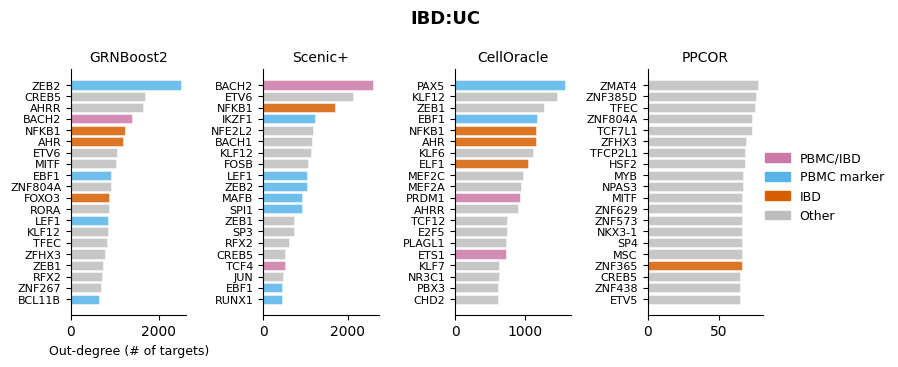

Saved: /home/jnourisa/projs/ongoing/geneRNBI/src/stability_analysis/ibd_biology/output/fig1_top20_tfs_uc.png
── Dataset: IBD:CD ──


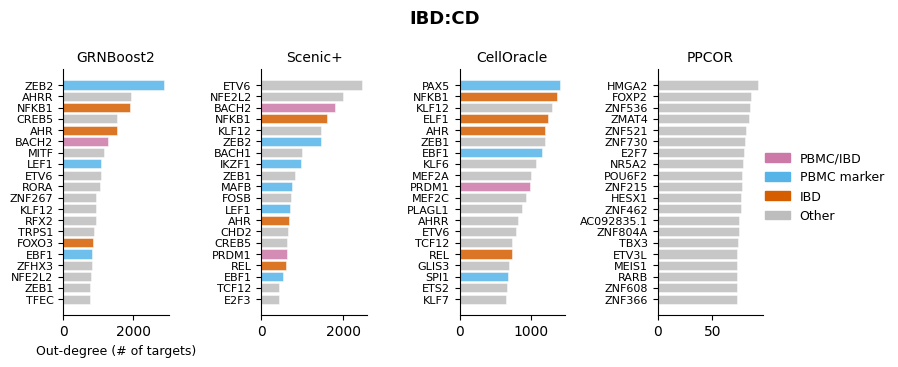

Saved: /home/jnourisa/projs/ongoing/geneRNBI/src/stability_analysis/ibd_biology/output/fig1_top20_tfs_cd.png


In [8]:
for label, key in DATASETS.items():
    print(f'── Dataset: IBD:{label} ──')
    fig_top_tfs(label, key)

## 3. GWAS Analysis

In [9]:
def get_ibd_gwas_genes(pvalue_mlog_min: float = 7.3):
    """Return IBD-associated gene symbols from GWAS Catalog (p < 5e-8 by default)."""
    gwas = pickle.load(open(GWAS_PATH, 'rb'))
    mask = gwas['DISEASE/TRAIT'].str.lower().str.contains(
        'inflammatory bowel|ulcerative colitis|crohn', na=False
    )
    ibd = gwas[mask]
    ibd = ibd[ibd['PVALUE_MLOG'] >= pvalue_mlog_min]
    genes = set()
    for col in ['REPORTED GENE(S)', 'MAPPED_GENE']:
        ibd[col].dropna().apply(
            lambda s: genes.update(
                g.strip() for g in s.replace(' - ', ', ').split(',')
                if g.strip() and g.strip() != 'NR'
            )
        )
    return genes

print('Loading IBD GWAS genes...')
gwas_genes = get_ibd_gwas_genes()
print(f'  {len(gwas_genes)} IBD-associated genes from GWAS Catalog')

Loading IBD GWAS genes...
  1207 IBD-associated genes from GWAS Catalog


In [10]:
def fig_gwas_indegree(dataset_label, dataset_key, gwas_genes):
    fig, axes = plt.subplots(1, 4, figsize=(9, 4.5))
    fig.suptitle(f'IBD:{dataset_label}', fontsize=13, fontweight='bold')
    for i, (ax, method) in enumerate(zip(axes, METHODS)):
        grn = load_grn(dataset_key, method)
        indeg = grn.groupby('target')['source'].count()
        gwas_indeg = indeg[indeg.index.isin(gwas_genes)].sort_values(ascending=False).head(30)
        if gwas_indeg.empty:
            ax.text(0.5, 0.5, 'No GWAS genes\nin network',
                    ha='center', va='center', transform=ax.transAxes)
        else:
            _hbar(ax, gwas_indeg.index.tolist(), gwas_indeg.values.tolist(),
                  METHOD_COLORS[method], ibd_set=IBD_GWAS_TFS)
        ax.set_xlabel('In-degree (# regulating TFs)' if i == 0 else '', fontsize=9)
        ax.set_title(surrogate_names[method], fontsize=10)

    legend_handles = [
        mpatches.Patch(color=_TF_COLOR_IBD,  label='IBD-associated'),
        mpatches.Patch(color=_TF_COLOR_NONE, label='Other'),
    ]
    fig.legend(handles=legend_handles, ncol=1, fontsize=9, frameon=False,
               loc='center right', bbox_to_anchor=(1.0, 0.5))
    plt.tight_layout(rect=[0, 0, 0.87, 1])
    out = os.path.join(OUT_DIR, f'fig2_gwas_indegree_{dataset_label.lower()}.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')


── Dataset: IBD:UC ──


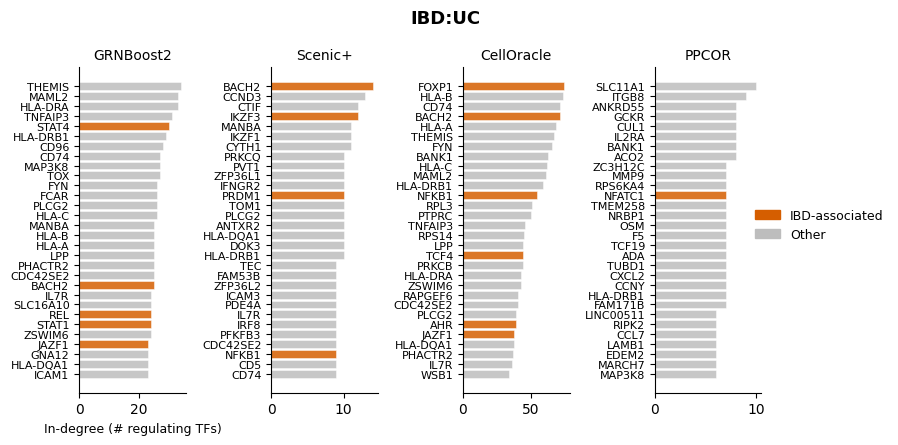

Saved: /home/jnourisa/projs/ongoing/geneRNBI/src/stability_analysis/ibd_biology/output/fig2_gwas_indegree_uc.png
── Dataset: IBD:CD ──


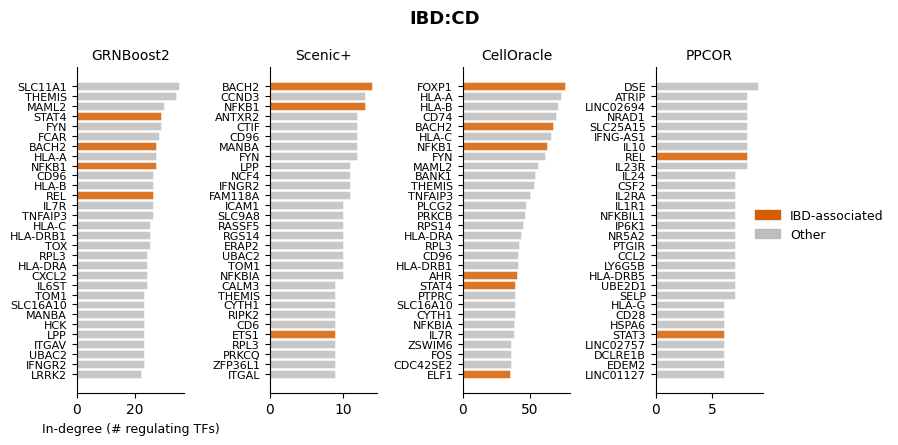

Saved: /home/jnourisa/projs/ongoing/geneRNBI/src/stability_analysis/ibd_biology/output/fig2_gwas_indegree_cd.png


In [11]:
for label, key in DATASETS.items():
    print(f'── Dataset: IBD:{label} ──')
    fig_gwas_indegree(label, key, gwas_genes)

## 3b. Annotated TF Coverage per Method

For each GRN method, take the union of TF sources across UC and CD, then compare against the annotated TF set (PBMC markers ∪ IBD GWAS TFs). Report how many are missing per method.

In [12]:
# ── Step 1: per method, union of TF sources across UC + CD ───────────────────
pbmc_set = set(PBMC_CORE_TFS)
ibd_set  = IBD_GWAS_TFS

method_tfs = {}
for m in METHODS:
    tfs = set()
    for ds in list(DATASETS.values()):
        grn = load_grn(ds, m)
        tfs |= set(grn['source'].unique())
    method_tfs[m] = tfs
    print(f'{surrogate_names[m]:12s}: {len(tfs):,} unique TFs (UC ∪ CD)')

# ── Step 2: universe = union across all methods ───────────────────────────────
universe_tfs = set().union(*method_tfs.values())
print(f'\nUniverse (all methods): {len(universe_tfs):,} unique TFs')

# ── Step 3: annotated TFs present anywhere in the universe ───────────────────
ann_in_universe = (pbmc_set | ibd_set) & universe_tfs
pbmc_in_u = pbmc_set & universe_tfs
ibd_in_u  = ibd_set  & universe_tfs
print(f'Annotated TFs in universe: {len(ann_in_universe)} '
      f'(PBMC={len(pbmc_in_u)}, '
      f'IBD-only={len(ibd_in_u - pbmc_set)}, '
      f'PBMC/IBD={len(pbmc_in_u & ibd_set)})')

# ── Step 4: missing per method ────────────────────────────────────────────────
method_missing = {}
rows = []
for m in METHODS:
    missing      = ann_in_universe - method_tfs[m]
    method_missing[m] = missing
    pbmc_only_m  = (missing & pbmc_set) - ibd_set
    ibd_only_m   = (missing & ibd_set)  - pbmc_set
    both_m       = missing & pbmc_set & ibd_set
    rows.append({
        'Method'     : surrogate_names[m],
        'Missing'    : len(missing),
        'Total'      : len(ann_in_universe),
        '% Missing'  : f'{100*len(missing)/len(ann_in_universe):.1f}%',
        'PBMC-only'  : len(pbmc_only_m),
        'IBD-only'   : len(ibd_only_m),
        'PBMC/IBD'   : len(both_m),
        'Missing TFs': ', '.join(sorted(missing)),
    })

df_missing = pd.DataFrame(rows)
display(df_missing[['Method','Missing','Total','% Missing','PBMC-only','IBD-only','PBMC/IBD']])

print('\nMissing TFs per method:')
for r in rows:
    print(f"  {r['Method']}: {r['Missing TFs'] if r['Missing TFs'] else 'none'}")

# ── Step 5: missed TFs per method with PBMC/IBD breakdown ───────────────────
print('\nMissed TFs per method:')
for m in METHODS:
    missing   = method_missing[m]
    miss_pbmc = sorted(missing & pbmc_set - ibd_set)
    miss_ibd  = sorted(missing & ibd_set  - pbmc_set)
    miss_both = sorted(missing & pbmc_set & ibd_set)
    print(f'  {surrogate_names[m]:12s}: {len(missing)} total')
    if miss_pbmc: print(f'    PBMC-only : {", ".join(miss_pbmc)}')
    if miss_ibd:  print(f'    IBD-only  : {", ".join(miss_ibd)}')
    if miss_both: print(f'    PBMC/IBD  : {", ".join(miss_both)}')
    if not missing: print(f'    → none')

GRNBoost2   : 1,158 unique TFs (UC ∪ CD)
Scenic+     : 380 unique TFs (UC ∪ CD)
CellOracle  : 488 unique TFs (UC ∪ CD)
PPCOR       : 1,157 unique TFs (UC ∪ CD)

Universe (all methods): 1,220 unique TFs
Annotated TFs in universe: 57 (PBMC=30, IBD-only=27, PBMC/IBD=6)


,Method,Missing,Total,% Missing,PBMC-only,IBD-only,PBMC/IBD
0,GRNBoost2,0,57,0.0%,0,0,0
1,Scenic+,23,57,40.4%,4,17,2
2,CellOracle,7,57,12.3%,1,6,0
3,PPCOR,0,57,0.0%,0,0,0



Missing TFs per method:
  GRNBoost2: none
  Scenic+: BATF, BCL11B, CAMTA1, ELF1, ETS1, FOSL2, FOXP1, GATA3, IKZF3, IRF1, IRF3, IRF4, JAZF1, SMAD3, SP110, SP140, STAT1, STAT4, STAT5B, TET2, ZBTB46, ZNF365, ZNF683
  CellOracle: CAMTA1, JAZF1, SP110, TET2, ZBTB46, ZEB2, ZNF365
  PPCOR: none

Missed TFs per method:
  GRNBoost2   : 0 total
    → none
  Scenic+     : 23 total
    PBMC-only : BATF, BCL11B, IRF4, ZNF683
    IBD-only  : CAMTA1, ELF1, FOSL2, FOXP1, IKZF3, IRF1, IRF3, JAZF1, SMAD3, SP110, SP140, STAT1, STAT4, STAT5B, TET2, ZBTB46, ZNF365
    PBMC/IBD  : ETS1, GATA3
  CellOracle  : 7 total
    PBMC-only : ZEB2
    IBD-only  : CAMTA1, JAZF1, SP110, TET2, ZBTB46, ZNF365
  PPCOR       : 0 total
    → none


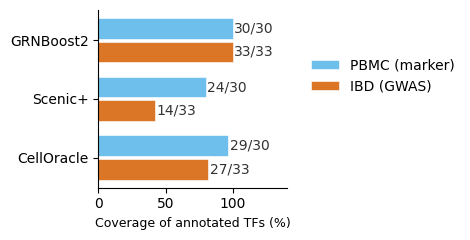

Saved: /home/jnourisa/projs/ongoing/geneRNBI/src/stability_analysis/ibd_biology/output/fig_tf_coverage.png


In [13]:
METHODS = ['grnboost', 'scenicplus', 'celloracle']
def fig_tf_coverage():
    # ── Compute coverage per method ───────────────────────────────────────────
    pbmc_set  = set(PBMC_CORE_TFS)
    ibd_set   = IBD_GWAS_TFS

    # union of TF sources per method across UC + CD
    m_tfs = {}
    for m in METHODS:
        tfs = set()
        for ds in DATASETS.values():
            tfs |= set(load_grn(ds, m)['source'].unique())
        m_tfs[m] = tfs

    universe = set().union(*m_tfs.values())
    pbmc_universe = pbmc_set & universe
    ibd_universe  = ibd_set  & universe

    # ── Build stats ───────────────────────────────────────────────────────────
    stats = []  # (method_label, category, covered, total, color)
    for m in METHODS:
        pbmc_cov = len(pbmc_universe & m_tfs[m])
        ibd_cov  = len(ibd_universe  & m_tfs[m])
        stats.append((surrogate_names[m], 'PBMC marker', pbmc_cov, len(pbmc_universe), _TF_COLOR_PBMC))
        stats.append((surrogate_names[m], 'IBD',         ibd_cov,  len(ibd_universe),  _TF_COLOR_IBD))

    # ── Plot ──────────────────────────────────────────────────────────────────
    method_labels = [surrogate_names[m] for m in METHODS]
    n_methods = len(METHODS)
    bar_h = 0.35

    fig, ax = plt.subplots(figsize=(5, 2.5))

    for i, m in enumerate(METHODS):
        mlabel = surrogate_names[m]
        for j, (cat, color, universe_set) in enumerate([
            ('PBMC (marker)', _TF_COLOR_PBMC, pbmc_universe),
            ('IBD (GWAS)',         _TF_COLOR_IBD,  ibd_universe),
        ]):
            cov   = len(universe_set & m_tfs[m])
            total = len(universe_set)
            pct   = 100 * cov / total if total > 0 else 0
            y     = i + (j - 0.5) * bar_h * 1.15  # offset two bars per method

            ax.barh(y, pct, height=bar_h, color=color, alpha=0.85,
                    edgecolor='white', linewidth=0.5, label=cat if i == 0 else '_')
            # annotate x/y at end of bar
            ax.text(pct + 1, y, f'{cov}/{total}',
                    va='center', ha='left', fontsize=10, color='#333333')

    ax.set_yticks(range(n_methods))
    ax.set_yticklabels(method_labels)
    ax.set_xlabel('Coverage of annotated TFs (%)', fontsize=9)
    ax.set_xlim(0, 140)
    # ax.axvline(100, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.spines[['top', 'right']].set_visible(False)
    ax.invert_yaxis()
    ax.legend(frameon=False, loc=[1.1, .5])
    plt.tight_layout()
    out = os.path.join(OUT_DIR, 'fig_tf_coverage.png')
    plt.savefig(out, dpi=150, bbox_inches='tight', transparent=True)
    plt.show()
    print(f'Saved: {out}')

fig_tf_coverage()


── GWAS TF summary (all models) ──


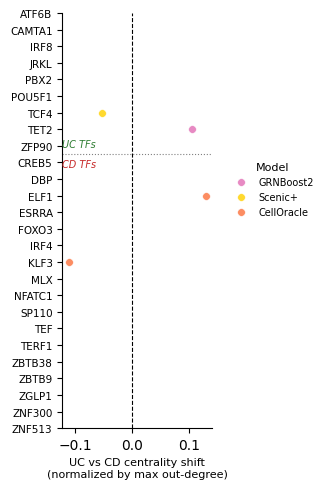

Saved: /home/jnourisa/projs/ongoing/geneRNBI/src/stability_analysis/ibd_biology/output/fig4_gwas_tf_summary.png


In [14]:
def fig_gwas_tf_summary():
    METHOD_MAP = {m: (surrogate_names[m], METHOD_COLORS[m]) for m in METHODS}

    gwas = pickle.load(open(GWAS_PATH, 'rb'))
    def parse_genes(s):
        if pd.isna(s): return []
        return [g.strip() for g in s.replace(' - ', ', ').split(',')
                if g.strip() and g.strip() != 'NR']

    tf_all = set(pd.read_csv('/vol/projects/jnourisa/genernbi/resources/grn_benchmark/prior/tf_all.csv')
                 .iloc[:, 0].astype(str).str.strip())

    def get_gwas_tfs(pattern, pvalue_mlog_min=7.3):
        mask = gwas['DISEASE/TRAIT'].str.lower().str.contains(pattern, na=False)
        subset = gwas[mask]
        subset = subset[subset['PVALUE_MLOG'] >= pvalue_mlog_min]
        genes = set()
        for col in ['REPORTED GENE(S)', 'MAPPED_GENE']:
            subset[col].dropna().apply(parse_genes).apply(genes.update)
        return genes & tf_all

    uc_tfs = get_gwas_tfs('ulcerative colitis')
    cd_tfs = get_gwas_tfs('crohn')
    uc_only = sorted(uc_tfs - cd_tfs)
    cd_only = sorted(cd_tfs - uc_tfs)

    method_deltas = {}
    for mkey in METHOD_MAP:
        grns = {cond: load_grn(ds, mkey) for cond, ds in DATASETS.items()}
        ods  = {cond: grn.groupby('source')['target'].count() for cond, grn in grns.items()}
        common = set(ods['UC'].index) & set(ods['CD'].index)
        delta = pd.Series({tf: ods['CD'].get(tf, 0) - ods['UC'].get(tf, 0) for tf in common})
        max_deg = max(ods['UC'].max(), ods['CD'].max())
        method_deltas[mkey] = delta / max_deg if max_deg > 0 else delta

    all_present = set().union(*[set(d.index) for d in method_deltas.values()])
    uc_only = [tf for tf in uc_only if tf in all_present]
    cd_only = [tf for tf in cd_only if tf in all_present]
    all_tfs   = uc_only + cd_only

    fig, ax = plt.subplots(figsize=(3.5, 5))
    y_pos = np.arange(len(all_tfs))

    avg_shifts = [np.nanmean([method_deltas[m].get(tf, np.nan) for m in METHOD_MAP])
                  for tf in all_tfs]
    bar_colors = ['#2e7d32' if v < 0 else '#c62828' for v in avg_shifts]
    # ax.barh(y_pos, avg_shifts, color=bar_colors, alpha=0.30, height=0.6,
    #         zorder=1, label='_nolegend_')

    dot_handles = []
    for mkey, (mlabel, mcolor) in METHOD_MAP.items():
        delta_ser = method_deltas[mkey]
        xs = [delta_ser.get(tf, np.nan) for tf in all_tfs]
        valid = [(x, y) for x, y in zip(xs, list(y_pos)) if (not np.isnan(x) and abs(x) > 0.05)]
        if valid:
            vx, vy = zip(*valid)
            sc = ax.scatter(vx, vy, color=mcolor, s=30, zorder=3,
                            edgecolors='white', linewidths=0.3, label=mlabel)
            dot_handles.append(sc)

    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(all_tfs, fontsize=7.5)
    ax.invert_yaxis()
    ax.set_xlabel('UC vs CD centrality shift\n(normalized by max out-degree)', fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

    sep = len(uc_only) - 0.5
    ax.axhline(sep, color='grey', linewidth=0.8, linestyle=':')
    ax.text(ax.get_xlim()[0], sep - 0.3, 'UC TFs', fontsize=7,
            color='#2e7d32', ha='left', va='bottom', style='italic')
    ax.text(ax.get_xlim()[0], sep + 0.3, 'CD TFs', fontsize=7,
            color='#c62828', ha='left', va='top', style='italic')

    ax.legend(handles=dot_handles, title='Model', loc=[1.1, 0.5],
                        fontsize=7, title_fontsize=8, frameon=False)
    # ax.add_artist(legend1)
    # bar_handles = [
    #     mpatches.Patch(color='#2e7d32', alpha=0.5, label='High in UC (avg)'),
    #     mpatches.Patch(color='#c62828', alpha=0.5, label='High in CD (avg)'),
    # ]
    # ax.legend(handles=bar_handles, loc='upper right', fontsize=7, frameon=True)

    plt.tight_layout()
    out = os.path.join(OUT_DIR, 'fig4_gwas_tf_summary.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')
print('── GWAS TF summary (all models) ──')
fig_gwas_tf_summary()

## 3c. Motif Database Coverage of Missing Annotated TFs

For each method, we ask: among the annotated TFs missed by that method, is the absence explained
by the TF having no motif in the underlying database, or does the TF have a motif but get filtered
out by the method's downstream enrichment thresholds?

- **CellOracle** uses [JASPAR2022](https://jaspar.elixir.no/) motifs (`JASPAR2022-hg38.bed.gz`).
- **SCENIC+** uses the aeretslab cisTarget v10 motif database (`motifs-v10-nr.hgnc-m0.00001-o0.0.tbl`).
- **GRaNIE** uses [HOCOMOCO v12](https://hocomoco12.autosome.org/) in-vivo motifs (`PWMScan_HOCOMOCOv12_H12INVIVO`).

In [ ]:
import gzip, os as _os

JASPAR_BED       = '/vol/projects/jnourisa/genernbi/resources/supp_data/databases/scglue/JASPAR2022-hg38.bed.gz'
MOTIF_SCENIC_TBL = '/vol/projects/jnourisa/genernbi/resources/supp_data/databases/scenicplus/motifs-v10-nr.hgnc-m0.00001-o0.0.tbl'
HOCOMOCO_DIR     = '/home/jnourisa/projs/ongoing/task_grn_inference/resources/supp_data/databases/granie/H12INVIVO'

# CellOracle: TF names from JASPAR2022 bed (col 4)
jaspar_tfs = set()
with gzip.open(JASPAR_BED, 'rt') as fh:
    for line in fh:
        parts = line.strip().split('\t')
        if len(parts) >= 4:
            jaspar_tfs.add(parts[3].upper())

# SCENIC+: gene_name column in tbl
sp_df = pd.read_csv(MOTIF_SCENIC_TBL, sep='\t', comment='#', header=None,
                    low_memory=False,
                    names=open(MOTIF_SCENIC_TBL).readline().strip().split('\t'))
sp_motif_tfs = set(sp_df['gene_name'].dropna().str.strip().str.upper())

# GRaNIE: TF names from HOCOMOCO v12 file names (part before first dot)
hocomoco_tfs = set(f.split('.')[0].upper() for f in _os.listdir(HOCOMOCO_DIR))

print(f'CellOracle motif TFs (JASPAR2022)  : {len(jaspar_tfs):,}')
print(f'SCENIC+    motif TFs (cisTarget v10): {len(sp_motif_tfs):,}')
print(f'GRaNIE     motif TFs (HOCOMOCO v12) : {len(hocomoco_tfs):,}')

method_motif_db = {
    'celloracle': jaspar_tfs,
    'scenicplus' : sp_motif_tfs,
    'granie'     : hocomoco_tfs,
}

pbmc_set = set(PBMC_CORE_TFS)
ibd_set  = IBD_GWAS_TFS

rows = []
print()
for m, motif_db in {k:v for k,v in method_motif_db.items() if k in method_missing}.items():
    missing = method_missing.get(m, set())
    no_motif  = {tf for tf in missing if tf not in motif_db}
    has_motif = missing - no_motif

    def _label(tf):
        cats = []
        if tf in pbmc_set: cats.append('PBMC')
        if tf in ibd_set:  cats.append('IBD')
        return '/'.join(cats) if cats else '—'

    print(f'── {surrogate_names[m]} ──────────────────')
    print(f'  Missing annotated TFs : {len(missing)}')
    print(f'  Absent from motif DB  : {len(no_motif)} → {sorted(no_motif)}')
    print(f'  Have motif, filtered  : {len(has_motif)} → {sorted(has_motif)}')
    print()
    for tf in missing:
        rows.append({'Method': surrogate_names[m], 'TF': tf,
                     'Category': _label(tf),
                     'Absent from DB': tf in no_motif})

df_motif = pd.DataFrame(rows)
if not df_motif.empty:
    pivot = (df_motif
             .assign(Status=df_motif['Absent from DB'].map({True:'No motif', False:'Motif present (filtered)'}))
             .groupby(['Method','Status'])['TF'].apply(lambda x: ', '.join(sorted(x)))
             .unstack(fill_value=''))
    display(pivot)

## 4. Centrality Shift UC → CD

In [16]:
def fig_centrality_shift():
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for ax, method in zip(axes, METHODS):
        grns = {cond: load_grn(ds, method) for cond, ds in DATASETS.items()}
        ods = {cond: grn.groupby('source')['target'].count()
               for cond, grn in grns.items()}

        common = set(ods['UC'].index) & set(ods['CD'].index)
        delta = pd.Series(
            {tf: ods['CD'].get(tf, 0) - ods['UC'].get(tf, 0) for tf in common}
        ).sort_values()

        top_uc = delta.head(10)
        top_cd = delta.tail(10)
        plot_data = pd.concat([top_uc, top_cd.iloc[::-1]])

        colors = ['#2e7d32' if v < 0 else '#c62828' for v in plot_data.values]
        y = range(len(plot_data))
        ax.barh(list(y), plot_data.values, color=colors, edgecolor='white', linewidth=0.4)
        ax.set_yticks(list(y))
        labels = [f'*{tf}' if tf in IBD_PBMC_TFS else tf for tf in plot_data.index]
        ax.set_yticklabels(labels, fontsize=7.5)
        ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
        ax.invert_yaxis()
        ax.set_xlabel('IBD: UC vs CD centrality shift', fontsize=9)
        ax.set_title(surrogate_names[method], fontweight='bold', fontsize=11)
        ax.spines[['top', 'right']].set_visible(False)

    legend_handles = [
        mpatches.Patch(color='#2e7d32', label='High in UC'),
        mpatches.Patch(color='#c62828', label='High in CD'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=2,
               fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.04))
    ax.annotate('* known PBMC/IBD TF', xy=(1.01, 0), xycoords='axes fraction',
                fontsize=7, color='grey')
    plt.tight_layout()
    out = os.path.join(OUT_DIR, 'fig3_centrality_shift_uc_cd.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')

── Centrality shift UC→CD ──


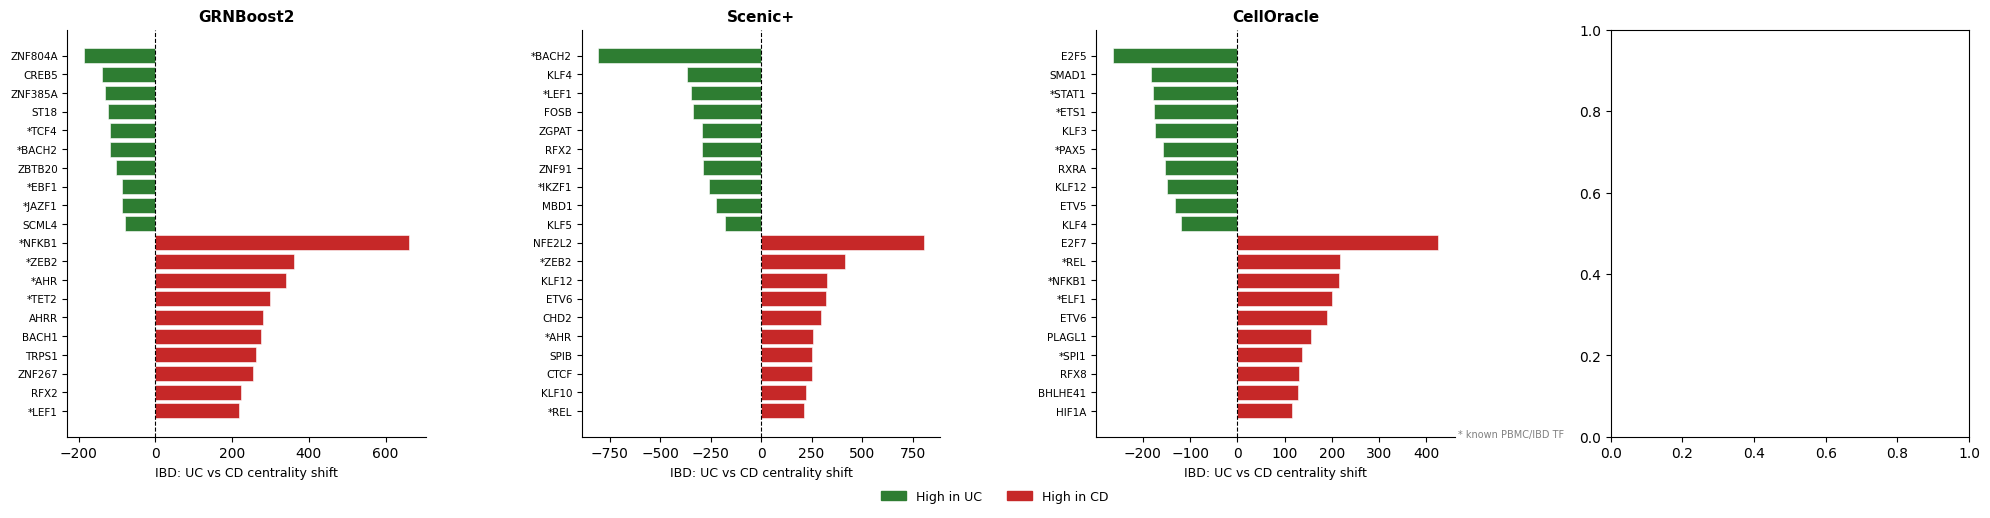

Saved: /home/jnourisa/projs/ongoing/geneRNBI/src/stability_analysis/ibd_biology/output/fig3_centrality_shift_uc_cd.png
Done.


In [17]:
print('── Centrality shift UC→CD ──')
fig_centrality_shift()
print('Done.')

## 5. CD vs UC Differential Network Analysis

Compares GRN edges between UC and CD for a selected model.  
Identifies:
- **CD-specific** and **UC-specific** edges (presence/absence)
- **Shared edges** with large weight shifts
- **TFs and target genes** most central to the differences
- **Biology match** against GWAS TFs and known IBD/PBMC TFs

In [18]:
# ── Parameters — change MODEL to any of: 'grnboost', 'scenicplus', 'celloracle', 'ppcor'
MODEL   = 'grnboost'
TOP_N   = 20   # top TFs / targets to show in bar charts
MIN_PVALUE_MLOG = 7.3  # genome-wide significance threshold for GWAS TF filter

In [19]:
grn_uc = load_grn('ibd_uc', MODEL).copy()
grn_cd = load_grn('ibd_cd', MODEL).copy()

# cast weight to float
grn_uc['weight'] = grn_uc['weight'].astype(float)
grn_cd['weight'] = grn_cd['weight'].astype(float)

edges_uc = set(zip(grn_uc['source'], grn_uc['target']))
edges_cd = set(zip(grn_cd['source'], grn_cd['target']))

cd_only_edges = edges_cd - edges_uc
uc_only_edges = edges_uc - edges_cd
shared_edges  = edges_uc & edges_cd

print(f"Model: {surrogate_names[MODEL]}")
print(f"  UC edges : {len(edges_uc):,}")
print(f"  CD edges : {len(edges_cd):,}")
print(f"  Shared   : {len(shared_edges):,}  ({100*len(shared_edges)/len(edges_uc):.1f}% of UC)")
print(f"  CD-only  : {len(cd_only_edges):,}")
print(f"  UC-only  : {len(uc_only_edges):,}")

df_cd_only = pd.DataFrame(list(cd_only_edges), columns=['source', 'target'])
df_uc_only = pd.DataFrame(list(uc_only_edges), columns=['source', 'target'])

Model: GRNBoost2
  UC edges : 50,000
  CD edges : 50,000
  Shared   : 25,463  (50.9% of UC)
  CD-only  : 24,537
  UC-only  : 24,537


In [20]:
# Out-degree of TFs in differential edge sets
tf_cd = df_cd_only.groupby('source')['target'].count().rename('cd_only')
tf_uc = df_uc_only.groupby('source')['target'].count().rename('uc_only')

# In-degree of target genes in differential edge sets
tgt_cd = df_cd_only.groupby('target')['source'].count().rename('cd_only')
tgt_uc = df_uc_only.groupby('target')['source'].count().rename('uc_only')

# Weight shift for shared edges
shared_df = (
    grn_uc.set_index(['source', 'target'])['weight']
    .rename('w_uc')
    .to_frame()
    .join(
        grn_cd.set_index(['source', 'target'])['weight'].rename('w_cd'),
        how='inner'
    )
)
shared_df['delta'] = shared_df['w_cd'] - shared_df['w_uc']

# TF net weight gain/loss in shared edges
tf_weight_delta = shared_df.groupby('source')['delta'].sum().sort_values()

NameError: name 'KNOWN_TFS' is not defined

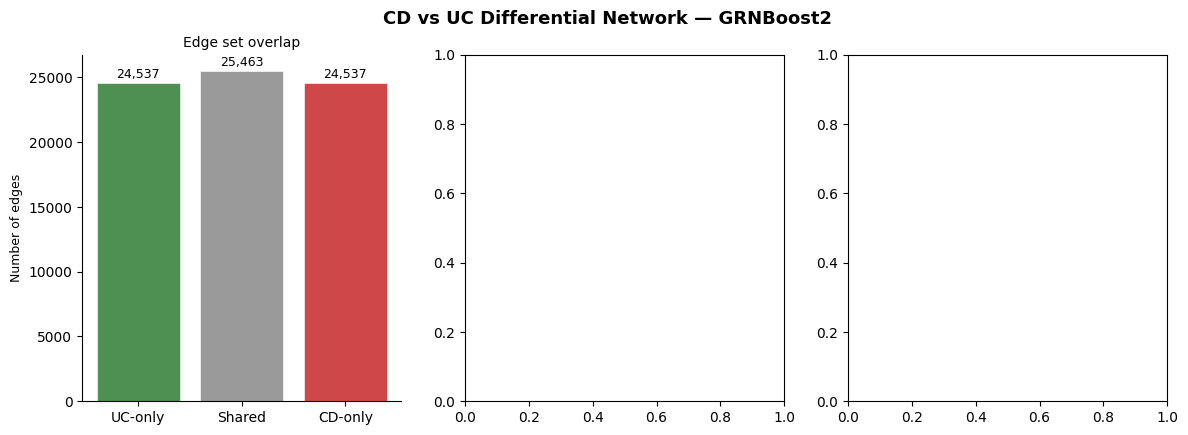

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle(f'CD vs UC Differential Network — {surrogate_names[MODEL]}',
             fontsize=13, fontweight='bold')

# Panel A: edge set breakdown
ax = axes[0]
counts = [len(uc_only_edges), len(shared_edges), len(cd_only_edges)]
labels = ['UC-only', 'Shared', 'CD-only']
bar_colors = ['#2e7d32', '#888888', '#c62828']
bars = ax.bar(labels, counts, color=bar_colors, edgecolor='white', linewidth=0.5, alpha=0.85)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{cnt:,}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Number of edges', fontsize=9)
ax.set_title('Edge set overlap', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

# Panel B: top TFs in CD-only edges
ax = axes[1]
top = tf_cd.sort_values(ascending=False).head(TOP_N)
bar_cols = [colors_blind[1] if tf in KNOWN_TFS else colors_blind[0] for tf in top.index]
y = range(len(top))
ax.barh(list(y), top.values, color=bar_cols, edgecolor='white', linewidth=0.4, alpha=0.8)
ax.set_yticks(list(y))
ax.set_yticklabels(top.index, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('# CD-specific edges', fontsize=9)
ax.set_title(f'Top {TOP_N} TFs in CD-only edges', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

# Panel C: top TFs in UC-only edges
ax = axes[2]
top = tf_uc.sort_values(ascending=False).head(TOP_N)
bar_cols = [colors_blind[1] if tf in KNOWN_TFS else colors_blind[0] for tf in top.index]
y = range(len(top))
ax.barh(list(y), top.values, color=bar_cols, edgecolor='white', linewidth=0.4, alpha=0.8)
ax.set_yticks(list(y))
ax.set_yticklabels(top.index, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('# UC-specific edges', fontsize=9)
ax.set_title(f'Top {TOP_N} TFs in UC-only edges', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

legend_handles = [mpatches.Patch(color=colors_blind[1], label='Known PBMC/IBD TF')]
fig.legend(handles=legend_handles, fontsize=8, frameon=False, bbox_to_anchor=(0.98, 0.12))
plt.tight_layout()
out = os.path.join(OUT_DIR, f'fig5a_diff_edges_tfs_{MODEL}.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')